# Variante de un algoritmo genético para el agente viajero

**Víctor Manuel Santos Martínez (253220020) · Jessica Melani Romero Lora (253220116)**
**Maestría en Inteligencia Artificial · Algoritmos Evolutivos · Actividad 02**
**Dr. Jaime Aguilar Ortiz · Septiembre de 2026**

## Propósito y alcance

Desarrollar una variante del problema del agente viajero cambiando el método de cinco de las siete
etapas de un algoritmo genético, y analizarla con nueve métricas repartidas en cuatro ejes. La
configuración de referencia es la del programa comentado que acompaña a la materia; los métodos
alternativos proceden de *SEMANA-02*, la guía de los treinta métodos.

El cuadernillo es **autocontenido**: no importa módulos `.py` propios ni descarga datos. Ejecutar
todas las celdas en orden con el entorno conda **science**, desde la carpeta del proyecto. Produce
CSV y JSON en `resultados/`, imágenes en `figuras/` y un resumen de cifras en
`resultados/RESUMEN.md`.

### Pregunta

Sobre una instancia sintética fija de veinte ciudades y con un presupuesto idéntico de evaluaciones,
¿qué efecto tiene sustituir el método de cinco etapas del ciclo genético, y qué muestran las métricas
que no muestra el costo final por sí solo?

### Lo que este trabajo no hace

- No busca el óptimo del agente viajero ni afirma haberlo encontrado. Con veinte ciudades existen
  $19!/2 \approx 6\times10^{16}$ recorridos distintos: no se enumeran y no hay certificado de optimalidad.
- No afirma que la variante sea superior. Una variante correctamente implementada que **no** mejora
  es un resultado válido, y se informa como tal si ocurre.
- No ajusta parámetros de forma retrospectiva para favorecer a ninguna de las dos configuraciones.
- Los costos son unidades abstractas de la matriz sintética, no kilómetros.

In [1]:
import os, sys
from pathlib import Path
os.environ.setdefault("MPLCONFIGDIR", str(Path.cwd() / ".cache-matplotlib"))
assert Path(sys.prefix).name == "science", f"Selecciona conda science; entorno actual: {sys.prefix}"
print("Entorno conda: science")
print("Python:", sys.version.split()[0])
print("Carpeta de trabajo:", Path.cwd().name)

Entorno conda: science
Python: 3.11.15
Carpeta de trabajo: Actividad 2


## A. El problema y por qué la representación lo decide todo

### A.1 Modelo del recorrido cerrado

Se consideran $d$ ciudades identificadas con los enteros de $0$ a $d-1$ y una matriz $D$ de costos
simétricos, con entradas finitas no negativas, $D_{ii}=0$ y $D_{ij}=D_{ji}$. Cada par de ciudades
admite conexión: no hay aristas prohibidas, ventanas de tiempo ni capacidades. Una ruta $\pi$ es una
permutación de los identificadores y se minimiza el costo del ciclo cerrado:

$$L(\pi)=\sum_{j=0}^{d-1} D_{\pi_j,\;\pi_{(j+1)\bmod d}}.$$

El índice modular incorpora el regreso desde la última ciudad a la primera. La matriz se construye
como $D=(A+A^{\top})/2$ con $A$ uniforme en $[0,100)$, de modo que **no se garantiza la desigualdad
triangular**: es una instancia sintética de costos, no una red vial.

### A.2 Claves aleatorias

El cromosoma **no es la ruta**. Es un vector de $d$ números reales en $[0,1)$, uno por ciudad: la
posición del gen identifica la ciudad y su valor expresa una prioridad. **Ordenar las claves produce
la ruta.**

$$\text{claves}=(0.70,\,0.10,\,0.90,\,0.40)\;\longrightarrow\;\text{ruta}=(1,3,0,2).$$

La consecuencia gobierna el resto del trabajo: cualquier vector de claves decodifica en una
permutación válida, de modo que **no existe el cromosoma inviable** y no hace falta reparación.
Por eso pueden aplicarse operadores de dominio real —promediar dos padres, sumar ruido gaussiano— a
un problema que aparentemente es de permutaciones (Bean, 1994).

De ahí se sigue la precaución que más pesa en este trabajo: la ruta depende sólo del **orden
relativo** de las claves, nunca de sus valores. Un operador que mejora la distribución de los valores
no mejora necesariamente la distribución de las rutas, porque el `argsort` descarta esa información.
La sección D.1 desarrolla el caso concreto en que esto importa.

In [2]:
"""Variante evolutiva del agente viajero: referencia, alternativa y métricas.

Instancia sintética declarada; los costos no representan distancias observadas.
Ninguna de las dos configuraciones recibe información sobre la otra ni sobre
el mejor recorrido conocido: éste se calcula al final, sólo para informar.
"""
from __future__ import annotations

from dataclasses import dataclass, field
from time import perf_counter
import numpy as np

### A.3 Instancia, decodificador y evaluación

Tres funciones sostienen todo lo demás. `generar_instancia` reproduce la construcción del programa
de la materia con la misma semilla de datos, de modo que ambas configuraciones compiten sobre
exactamente la misma matriz. `decodificar` convierte claves en ruta. `costo_ruta` audita una ruta
explícita y es la que permite comprobar, al final, que el costo informado corresponde al recorrido
que se devuelve.

In [3]:
def generar_instancia(num_ciudades: int, semilla: int) -> np.ndarray:
    """Construye la matriz simétrica sintética D=(A+A.T)/2 con A uniforme en [0,100).

    Usa su propio generador: la semilla de los datos es independiente de la
    semilla algorítmica, de modo que cambiar una no altera la otra.
    """
    if not isinstance(num_ciudades, int) or num_ciudades < 3:
        raise ValueError("Se requieren al menos tres ciudades.")
    rng = np.random.default_rng(semilla)
    a = rng.random((num_ciudades, num_ciudades)) * 100.0
    matriz = (a + a.T) / 2.0
    np.fill_diagonal(matriz, 0.0)
    if not np.allclose(matriz, matriz.T) or np.any(matriz < 0) or not np.all(np.isfinite(matriz)):
        raise ValueError("Matriz de costos inválida.")
    return matriz

In [4]:
def decodificar(claves) -> np.ndarray:
    """Ordena las claves para obtener la ruta y la rota para empezar en la ciudad 0.

    argsort devuelve las POSICIONES ordenadas por valor de clave, que son los
    identificadores de ciudad. El orden estable resuelve empates por identificador.
    Rotar el ciclo para presentarlo desde la ciudad 0 no cambia sus conexiones
    ni su costo; sólo facilita comparar dos rutas a simple vista.
    """
    claves = np.asarray(claves, dtype=float)
    if claves.ndim != 1 or not np.all(np.isfinite(claves)):
        raise ValueError("Se requiere un vector finito de claves.")
    ruta = np.argsort(claves, kind="stable")
    return np.roll(ruta, -int(np.flatnonzero(ruta == 0)[0]))

In [5]:
def costo_ruta(ruta, matriz) -> float:
    """Audita una ruta explícita: comprueba que sea una permutación y suma el ciclo.

    np.roll entrega la ciudad siguiente de cada tramo y, en la última posición,
    la primera ciudad. Se usa para verificar el resultado final, no dentro del
    ciclo evolutivo, donde la evaluación vectorizada cumple esa función.
    """
    ruta = np.asarray(ruta)
    d = len(matriz)
    if ruta.shape != (d,) or not np.issubdtype(ruta.dtype, np.integer):
        raise ValueError("La ruta debe contener un identificador entero por ciudad.")
    if not np.array_equal(np.sort(ruta), np.arange(d)):
        raise ValueError("La ruta debe visitar cada ciudad exactamente una vez.")
    return float(np.sum(matriz[ruta, np.roll(ruta, -1)]))

In [6]:
def evaluar(poblacion, matriz) -> np.ndarray:
    """Evalúa una población completa de claves. Una fila cuenta como una evaluación.

    Se decodifica cada fila con argsort y se suman los tramos del ciclo. El
    cálculo es vectorizado, pero la convención de conteo sigue siendo por
    individuo: veinte filas son veinte evaluaciones aunque haya una sola llamada.
    """
    p = np.asarray(poblacion, dtype=float)
    if p.ndim != 2 or p.shape[1] != len(matriz):
        raise ValueError("Población inválida.")
    rutas = np.argsort(p, axis=1, kind="stable")
    siguientes = np.roll(rutas, -1, axis=1)
    return matriz[rutas, siguientes].sum(axis=1)

## B. La configuración de referencia

Es la del programa comentado que acompaña a la materia: una combinación fija de siete métodos, uno
por etapa. Se reimplementa aquí para que ambas configuraciones recorran **el mismo motor** y la
comparación no dependa de diferencias de instrumentación.

| Etapa | Método | Descripción |
|---|---|---|
| 1. Inicialización | M01 | Muestreo uniforme independiente en $[0,1)^d$ |
| 2. Evaluación | M05 | Evaluación directa del costo del ciclo |
| 3. Selección | M12 | Torneo determinista, participantes sorteados con reemplazo |
| 4. Recombinación | M14 | Cruce uniforme por máscara sobre claves |
| 5. Mutación | M18 | Reinicialización uniforme por gen |
| 6. Reemplazo | M22 | Generacional con elitismo explícito |
| 7. Paro | M25 | Número máximo de generaciones |

Parámetros: 20 ciudades, población 100, 500 generaciones, 2 élites, torneo de tamaño 3, probabilidad
de cruce 0.90, máscara 0.50 y mutación por gen $1/d=0.05$. Semilla de datos 20260917.

In [7]:
def m01_inicializar(n: int, d: int, rng: np.random.Generator) -> np.ndarray:
    """M01. Muestreo uniforme independiente: cada clave es U[0,1) sin estructura.

    Es la inicialización de la referencia y también la que conserva la variante.
    La sección D.1 explica por qué estratificar las claves no aportaría rutas
    más diversas con esta representación.
    """
    return rng.random((n, d))

In [8]:
def m12_torneo(costos, cantidad: int, k: int, rng: np.random.Generator) -> np.ndarray:
    """M12. Torneo determinista entre k participantes sorteados CON reemplazo.

    Gana el menor costo; el empate conserva la primera aparición sorteada. Un
    individuo puede competir y ganar varias veces. Devuelve índices, no cromosomas.
    """
    costos = np.asarray(costos, dtype=float)
    participantes = rng.integers(0, len(costos), size=(cantidad, k))
    ganadores = np.argmin(costos[participantes], axis=1)
    return participantes[np.arange(cantidad), ganadores]

In [9]:
def m14_cruce_uniforme(a, b, rng: np.random.Generator, q: float = 0.5):
    """M14. Máscara de Bernoulli que decide, gen a gen, la procedencia de la clave.

    Los hijos son complementarios: donde uno toma del primer padre, el otro toma
    del segundo. Con q=0.5 ningún padre está favorecido. Esta q es distinta de la
    probabilidad de aplicar el cruce a una pareja, que decide el ciclo.
    """
    mascara = rng.random(len(a)) < q
    return np.where(mascara, a, b), np.where(mascara, b, a)

In [10]:
def m18_reinicio(x, p: float, rng: np.random.Generator) -> np.ndarray:
    """M18. Cada clave se reinicia con probabilidad p a un nuevo U[0,1).

    Es una probabilidad POR GEN. Con p=1/d se reinicia un gen en promedio, no
    exactamente uno. Devuelve un vector nuevo: nunca modifica a un padre.
    """
    mascara = rng.random(len(x)) < p
    return np.where(mascara, rng.random(len(x)), x)

In [11]:
def m22_generacional_elitista(poblacion, costos, hijos, costos_hijos, e: int):
    """M22. Conserva las e mejores claves parentales y acepta TODOS los N-e hijos.

    Los hijos entran sin competir contra los padres no élite. Con al menos una
    élite el mejor costo no puede empeorar, pero eso conserva lo hallado; no
    implica que vaya a aparecer algo mejor.
    """
    elite = np.argsort(costos, kind="stable")[:e]
    return (np.vstack((poblacion[elite], hijos)),
            np.concatenate((costos[elite], costos_hijos)))

In [12]:
def m25_parar_generaciones(generacion: int, maximo: int) -> bool:
    """M25. Paro por número de transiciones completadas. No incrementa contadores."""
    return generacion >= maximo

## C. La variante: cinco etapas cambiadas y dos conservadas

| Etapa | Referencia | Variante | Naturaleza del cambio |
|---|---|---|---|
| 1. Inicialización | M01 uniforme | **M01 conservada** | Ver C.1 |
| 2. Evaluación | M05 directa | **M05 conservada** | Ver C.2 |
| 3. Selección | M12 torneo | **M11 ranking lineal** | La probabilidad deja de depender de la magnitud del costo |
| 4. Recombinación | M14 uniforme | **M15 aritmético convexo** | De intercambiar claves a interpolarlas |
| 5. Mutación | M18 reinicio | **M19 gaussiana con proyección** | De reemplazar una clave a desplazarla |
| 6. Reemplazo | M23 conjunto | **M23 $(\mu+\lambda)$** | Padres e hijos compiten en un mismo conjunto |
| 7. Paro | M25 generaciones | **M26 presupuesto de evaluaciones** | Consecuencia obligada del anterior |

Cambiar el método de una etapa no es cambiar un parámetro. Mover la semilla, el tamaño de la
población o la probabilidad de cruce no demuestra una variante; sustituir M12 por M11 sí. Por eso se
mantienen idénticos población, probabilidad de cruce, número de élites conceptual y presupuesto de
evaluaciones: lo único que cambia entre las dos configuraciones es el **método** de cinco etapas.

### C.1 Por qué se conserva M01 en la inicialización

Las alternativas son M02 Bernoulli, M03 hipercubo latino y M04 Dirichlet. M02 representa bits y no
corresponde a claves reales; M04 impone que las coordenadas sumen uno, condición que este problema
no tiene. Queda M03, y es el caso interesante.

El hipercubo latino estratifica cada coordenada: reparte los $N$ individuos en $N$ franjas por gen y
sortea uno dentro de cada franja. Eso mejora la cobertura de la caja $[0,1)^d$. **Pero esa cobertura
no sobrevive al decodificador.** La ruta depende sólo del orden relativo de las claves dentro de un
individuo, y para un individuo aislado los estratos de sus distintas coordenadas se asignan con
permutaciones independientes, de modo que su vector sigue siendo esencialmente uniforme y su
permutación también. El `argsort` descarta precisamente la información que el hipercubo organiza.

La sección F.3 lo mide en lugar de suponerlo: compara la diversidad de rutas de poblaciones
iniciales generadas con M01 y con M03.

### C.2 Por qué se conserva M05 en la evaluación

Las alternativas son M06 suma ponderada, M07 penalización estática y M08 reglas de factibilidad de
Deb. Las tres necesitan algo que este problema no tiene: un segundo objetivo o restricciones que
puedan violarse. Con claves aleatorias **toda ruta es factible**, de modo que penalizar
incumplimientos que nunca ocurren no cambiaría ningún resultado, y añadir un segundo objetivo
inventado sólo para poder declarar la etapa cambiada alteraría el problema y volvería inválida la
comparación contra la referencia.

Conservarla con un argumento es preferible a cambiarla con una etiqueta. Si el criterio de la
actividad exigiera cambiar las siete, la salida honesta sería modificar el modelo —por ejemplo
añadir como segundo objetivo el tramo más largo del recorrido, para castigar saltos
desproporcionados— y declarar que a partir de ahí se compara otro problema.

In [13]:
def m11_ranking(costos, cantidad: int, presion: float, rng: np.random.Generator) -> np.ndarray:
    """M11. Ranking lineal de minimización: la posición ordenada fija la probabilidad.

    p_i = (1/N)[s - 2(s-1) r_i /(N-1)], con r_i=0 para el mejor y N-1 para el peor.
    Los empates reciben el promedio de las posiciones que ocuparían, para no
    favorecer a quien aparece antes en la tabla. Multiplicar todos los costos por
    una constante positiva no altera la selección: ésa es la diferencia con una
    ruleta proporcional, y el motivo de haber elegido este método.
    """
    costos = np.asarray(costos, dtype=float)
    n = len(costos)
    if n < 2 or not 1.0 <= presion <= 2.0:
        raise ValueError("Se requiere N >= 2 y presión en [1, 2].")
    orden = np.argsort(costos, kind="stable")
    rangos = np.empty(n, dtype=float)
    i = 0
    while i < n:                       # Agrupar empates exactos y darles rango medio.
        j = i + 1
        while j < n and costos[orden[j]] == costos[orden[i]]:
            j += 1
        rangos[orden[i:j]] = (i + j - 1) / 2.0
        i = j
    p = (presion - 2.0 * (presion - 1.0) * rangos / (n - 1)) / n
    p = np.maximum(p, 0.0)
    return rng.choice(n, size=cantidad, replace=True, p=p / p.sum())

In [14]:
def m15_aritmetico(a, b, alpha: float):
    """M15. Recombinación aritmética convexa: los hijos caen sobre el segmento (a, b).

    h1 = alpha*a + (1-alpha)*b   y   h2 = (1-alpha)*a + alpha*b.

    El coeficiente es un escalar común a todo el vector, no uno por gen. Con
    alpha=0.5 ambos hijos coincidirían en el punto medio, lo que destruiría
    variedad en cada cruce; por eso el ciclo sortea alpha en (0,1) antes de
    llamar a esta función, que no consume aleatoriedad propia.

    Advertencia registrada: este operador SÓLO interpola. Nunca produce claves
    fuera del intervalo que definen los padres, de modo que contrae la población
    hacia su centro a lo largo de las generaciones. La métrica de diversidad de
    la sección E lo vigila explícitamente.
    """
    a, b = np.asarray(a, dtype=float), np.asarray(b, dtype=float)
    if a.shape != b.shape:
        raise ValueError("Los progenitores deben tener la misma longitud.")
    if not 0.0 <= alpha <= 1.0:
        raise ValueError("alpha debe pertenecer a [0, 1].")
    return alpha * a + (1.0 - alpha) * b, (1.0 - alpha) * a + alpha * b

In [15]:
def m19_gaussiana(x, p: float, sigma: float, rng: np.random.Generator) -> np.ndarray:
    """M19. Ruido normal por gen seleccionado, con proyección posterior sobre [0,1).

    M_j ~ Bernoulli(p), Z_j ~ N(0,1), y_j = clip(x_j + M_j * sigma * Z_j, 0, 1).

    El recorte no produce una normal truncada: acumula probabilidad en los
    bordes. Se mantiene p = 1/d, igual que la referencia, para que entre las dos
    configuraciones cambie el operador y no su frecuencia de aplicación.

    Sigma es el parámetro crítico y no se elige a ojo: la sección F.2 mide qué
    fracción de mutaciones llega a alterar la ruta decodificada para varios
    valores, porque un desplazamiento pequeño puede conservar el orden y dejar
    la mutación sin efecto alguno sobre el fenotipo.
    """
    x = np.asarray(x, dtype=float)
    if sigma < 0:
        raise ValueError("sigma debe ser no negativo.")
    mascara = rng.random(len(x)) < p
    provisional = x + mascara * rng.normal(0.0, sigma, size=len(x))
    return np.clip(provisional, 0.0, 1.0)

In [16]:
def m23_mas(poblacion, costos, hijos, costos_hijos):
    """M23. Supervivencia (mu + lambda): padres e hijos compiten en un solo conjunto.

    Sobreviven los mu mejores de la unión, donde mu es el tamaño de la población.
    No hay un número fijo de padres que deba permanecer: pueden quedar muchos,
    pocos o ninguno si suficientes hijos los superan. El mejor costo no empeora,
    porque el conjunto de candidatos contiene a toda la población anterior.

    El orden estable hace que, ante costos idénticos, el padre preceda al hijo.
    Acepta lotes de hijos de cualquier tamaño, lo que permite que M26 autorice
    un último lote incompleto sin alterar el tamaño residente.
    """
    mu = len(poblacion)
    candidatos = np.vstack((poblacion, hijos))
    criterios = np.concatenate((costos, costos_hijos))
    elegidos = np.argsort(criterios, kind="stable")[:mu]
    return candidatos[elegidos].copy(), criterios[elegidos].copy()

In [17]:
def m26_presupuesto(evaluaciones: int, presupuesto: int, propuestas: int):
    """M26. Autoriza trabajo nuevo ANTES de consumirlo, nunca después de excederse.

    Devuelve (parar, cantidad_admisible), donde la cantidad se limita al saldo
    disponible. Un contador que ya supera el presupuesto es un error explícito y
    no una situación que se corrija en silencio. La función no consume
    evaluaciones: quien llama debe actualizar el contador al evaluar de verdad.
    """
    if evaluaciones > presupuesto:
        raise ValueError("El contador ya excede el presupuesto declarado.")
    disponibles = min(propuestas, presupuesto - evaluaciones)
    return disponibles == 0, disponibles

### C.3 Dispersión poblacional

El ciclo registra en cada transición la dispersión de la población, definida como en M29 de
*SEMANA-02*. Con las claves ya en $[0,1)$ la normalización por cotas es la identidad:

$$D(P)=\sqrt{\frac{1}{Nd}\sum_{i=1}^{N}\sum_{j=1}^{d}\bigl(x_{ij}-\bar x_j\bigr)^2}.$$

Es una desviación cuadrática media global, no una distancia media por parejas. Vale cero si todos
los individuos coinciden y no puede superar 0.5 en la caja unitaria. No se usa aquí como criterio de
paro sino como diagnóstico: mide concentración, no calidad. Veinte copias de una mala solución
también dan dispersión cero.

In [18]:
def dispersion(poblacion) -> float:
    """Dispersión poblacional normalizada (M29). Cero indica individuos idénticos.

    Las claves ya viven en [0,1), de modo que normalizar por las cotas es la
    identidad y la medida queda directamente comparable entre configuraciones.
    Es un diagnóstico de concentración: no mide calidad ni prueba convergencia.
    """
    p = np.asarray(poblacion, dtype=float)
    if p.ndim != 2 or len(p) < 2:
        return 0.0
    return float(np.sqrt(((p - p.mean(axis=0)) ** 2).mean()))

### C.4 Por qué M23 obliga a M26

Es el punto fino de la variante y conviene dejarlo explícito.

En la referencia, M22 reserva $e=2$ élites y produce exactamente $N-e=98$ hijos por generación. El
trabajo por transición es fijo, de modo que contar generaciones equivale a contar evaluaciones:
$E = N + G(N-e) = 100 + 500\times98 = 49\,100$.

M23 no reserva plazas: padres e hijos compiten por las $\mu=N$ posiciones. La elección natural es
$\lambda=\mu=100$ hijos por transición, que es un trabajo por generación **distinto** del de la
referencia. Si ambas configuraciones se detuvieran a las 500 generaciones, la variante habría
consumido $100+500\times100=50\,100$ evaluaciones frente a $49\,100$: dos por ciento más de esfuerzo,
y cualquier ventaja podría atribuirse a haber trabajado más.

Cambiar el criterio de paro no es cosmético, entonces, sino la condición para que la comparación
signifique algo. Con M26 ambas configuraciones se detienen en **exactamente 49 100 evaluaciones de
búsqueda**: la referencia tras 500 transiciones y la variante tras 490. Comparar por generaciones
sería injusto; comparar por presupuesto es lo correcto.

## D. El motor: un solo ciclo para las dos configuraciones

Las dos configuraciones recorren **la misma función**. Lo único que cambia es el objeto `Config` que
declara qué método usa cada etapa. Así ninguna diferencia observada puede atribuirse a la
instrumentación, al conteo de evaluaciones o al registro del historial.

El orden efectivo del ciclo es el de la materia: inicializar, evaluar, control de paro, seleccionar,
recombinar, mutar, reevaluar y reemplazar. Reevaluar a los hijos es repetir la etapa 2, no una
octava etapa.

In [19]:
@dataclass(frozen=True)
class Config:
    """Declara qué método ocupa cada etapa y con qué parámetros.

    Mantener los parámetros compartidos idénticos entre configuraciones es lo
    que permite atribuir las diferencias al método y no al ajuste.
    """
    nombre: str
    seleccion: str            # "M12" torneo | "M11" ranking lineal
    recombinacion: str        # "M14" uniforme | "M15" aritmético convexo
    mutacion: str             # "M18" reinicio | "M19" gaussiana con proyección
    reemplazo: str            # "M22" generacional elitista | "M23" (mu+lambda)
    paro: str                 # "M25" generaciones | "M26" presupuesto
    poblacion: int = 100
    elites: int = 2           # Sólo interviene con M22.
    torneo: int = 3           # Sólo interviene con M12.
    presion: float = 1.7      # Sólo interviene con M11.
    prob_cruce: float = 0.90
    sigma: float = 0.15       # Sólo interviene con M19; se calibra en F.2.
    generaciones: int = 500   # Sólo interviene con M25.
    presupuesto: int = 49_100 # Sólo interviene con M26.

    def etiqueta_metodos(self) -> str:
        return " · ".join(["M01", "M05", self.seleccion, self.recombinacion,
                           self.mutacion, self.reemplazo, self.paro])

In [20]:
def ejecutar(cfg: Config, matriz: np.ndarray, semilla: int) -> dict:
    """Ejecuta una corrida completa y devuelve solución, historial y contadores.

    Un único generador gobierna toda la evolución y nunca se reinicia por
    generación: repetir la semilla reproduce la corrida entera.

    El historial registra, por transición, el mejor y el promedio de la población
    residente, la dispersión poblacional y el número acumulado de evaluaciones.
    Guardar las evaluaciones junto al mejor costo es lo que permite comparar
    trayectorias entre configuraciones cuyo trabajo por generación difiere.
    """
    d = len(matriz)
    n, e = cfg.poblacion, cfg.elites
    pm = 1.0 / d
    rng = np.random.default_rng(semilla)
    inicio = perf_counter()

    poblacion = m01_inicializar(n, d, rng)                 # ETAPA 1: M01
    costos = evaluar(poblacion, matriz)                    # ETAPA 2: M05
    evaluaciones = n
    generacion = 0
    mejor_costo = float(costos.min())
    mejores_claves = poblacion[int(costos.argmin())].copy()
    inicial = mejor_costo
    historial = [dict(generacion=0, evaluaciones=evaluaciones, mejor=mejor_costo,
                      promedio=float(costos.mean()), dispersion=dispersion(poblacion))]

    while True:
        # ETAPA 7: autorizar ANTES de trabajar, no comprobar después.
        propuestos = (n - e) if cfg.reemplazo == "M22" else n
        if cfg.paro == "M25":
            if m25_parar_generaciones(generacion, cfg.generaciones):
                break
            cantidad = propuestos
        else:
            parar, cantidad = m26_presupuesto(evaluaciones, cfg.presupuesto, propuestos)
            if parar:
                break
            if cfg.reemplazo == "M22" and cantidad < propuestos:
                break   # M22 exige exactamente N-e hijos; un lote parcial no le sirve.

        # ETAPA 3: selección de progenitores.
        parejas = (cantidad + 1) // 2
        if cfg.seleccion == "M12":
            indices = m12_torneo(costos, 2 * parejas, cfg.torneo, rng)
        else:
            indices = m11_ranking(costos, 2 * parejas, cfg.presion, rng)

        hijos = np.empty((cantidad, d), dtype=float)
        puesto = 0
        for pareja in range(parejas):
            a, b = poblacion[indices[2 * pareja]], poblacion[indices[2 * pareja + 1]]
            if rng.random() < cfg.prob_cruce:              # ETAPA 4
                if cfg.recombinacion == "M14":
                    h1, h2 = m14_cruce_uniforme(a, b, rng, q=0.5)
                else:
                    # alpha se sortea fuera del operador; alpha=0.5 fijo haría
                    # que los dos hijos coincidieran en el punto medio.
                    h1, h2 = m15_aritmetico(a, b, float(rng.uniform(0.0, 1.0)))
            else:
                h1, h2 = a.copy(), b.copy()
            for h in (h1, h2):
                if puesto == cantidad:
                    break
                hijos[puesto] = (m18_reinicio(h, pm, rng) if cfg.mutacion == "M18"
                                 else m19_gaussiana(h, pm, cfg.sigma, rng))   # ETAPA 5
                puesto += 1

        costos_hijos = evaluar(hijos, matriz)              # REPETIR ETAPA 2
        evaluaciones += cantidad
        if cfg.reemplazo == "M22":                         # ETAPA 6
            poblacion, costos = m22_generacional_elitista(poblacion, costos, hijos,
                                                          costos_hijos, e)
        else:
            poblacion, costos = m23_mas(poblacion, costos, hijos, costos_hijos)
        generacion += 1

        # El índice sale de los costos NUEVOS y se aplica a la población NUEVA.
        actual = float(costos.min())
        if actual > mejor_costo + 1e-12:
            raise RuntimeError("El mejor costo empeoró: revisar la política de reemplazo.")
        if actual < mejor_costo:
            mejor_costo = actual
            mejores_claves = poblacion[int(costos.argmin())].copy()
        historial.append(dict(generacion=generacion, evaluaciones=evaluaciones,
                              mejor=mejor_costo, promedio=float(costos.mean()),
                              dispersion=dispersion(poblacion)))

    # Auditoría final: recuperar la ruta y recalcular su costo de forma directa.
    ruta = decodificar(mejores_claves)
    verificado = costo_ruta(ruta, matriz)
    if not np.isclose(verificado, mejor_costo, rtol=1e-12, atol=1e-10):
        raise RuntimeError("La ruta devuelta no corresponde a su costo almacenado.")
    return dict(configuracion=cfg.nombre, semilla=semilla, ruta=ruta.tolist(),
                costo=mejor_costo, costo_verificado=verificado, inicial=inicial,
                generaciones=generacion, evaluaciones=evaluaciones, auditorias=1,
                segundos=perf_counter() - inicio, historial=historial)

## E. Las nueve métricas

La consigna pide al menos cinco medidas que permitan analizar el modelo. Se emplean nueve, y el
criterio para elegirlas no fue acumular estadísticos sino **cubrir cuatro ejes distintos**: seis
vistas del costo final habrían cumplido el número sin describir nada nuevo.

| # | Métrica | Eje | Definición | Unidad y lectura |
|---|---|---|---|---|
| 1 | Costo final | Calidad | Costo recalculado del mejor recorrido | Unidades de $D$; menor es mejor |
| 2 | Mejora relativa | Calidad | $100(b_0-b_f)/b_0$ | Porcentaje frente al mejor inicial de esa corrida |
| 3 | Costo medio | Calidad | Promedio de $b_f$ entre semillas | Unidades de $D$ |
| 4 | Desviación estándar | Calidad | Desviación muestral de $b_f$ entre semillas | Unidades de $D$; estabilidad |
| 5 | Evaluaciones | Esfuerzo | Candidatos evaluados, incluida la inicialización | Conteo; moneda de comparación |
| 6 | Tiempo | Esfuerzo | Segundos del bloque de búsqueda | Depende del equipo |
| 7 | Dispersión final | Búsqueda | $D(P)$ de la población al terminar | Adimensional; cero es población idéntica |
| 8 | Tasa de acierto | Búsqueda | Semillas que quedan dentro del 1 % del mejor conocido | Porcentaje |
| 9 | Evaluaciones al 95 % | Búsqueda | Evaluaciones hasta lograr el 95 % de la mejora de esa corrida | Conteo; velocidad |

Tres precauciones que conviene sostener al leerlas.

**La métrica 2 no es una brecha de optimalidad.** Mide la distancia recorrida desde un punto de
partida que fue aleatorio, no la distancia que falta hasta el óptimo. Una corrida con mala
inicialización puede exhibir una mejora relativa mayor y terminar peor.

**La métrica 8 tampoco mide optimalidad.** El "mejor conocido" es simplemente el menor costo hallado
entre las sesenta corridas de este estudio. No hay certificado de que sea el óptimo, y con veinte
ciudades no se puede obtener por enumeración. Es un punto de referencia común para ambas
configuraciones, nada más.

**Las métricas 3 y 4 son entre corridas, no entre individuos de una generación.** Con menos de dos
repeticiones la 4 no se estima.

In [21]:
def metricas_corrida(r: dict, mejor_conocido: float, umbral: float = 0.95) -> dict:
    """Calcula las métricas de una sola corrida a partir de su historial.

    La métrica 9 localiza la primera transición en la que la corrida alcanzó el
    umbral de su PROPIA mejora total, y devuelve las evaluaciones acumuladas en
    ese punto. Usar la mejora propia y no el mejor conocido evita premiar a una
    corrida sólo por haber partido de una población inicial desafortunada.
    """
    historial = r["historial"]
    b0, bf = r["inicial"], r["costo"]
    mejora = b0 - bf
    objetivo = b0 - umbral * mejora
    evaluaciones_umbral = r["evaluaciones"]
    for h in historial:
        if h["mejor"] <= objetivo:
            evaluaciones_umbral = h["evaluaciones"]
            break
    return dict(
        configuracion=r["configuracion"], semilla=r["semilla"],
        costo=bf, inicial=b0,
        mejora_pct=100.0 * mejora / b0 if b0 > 0 else 0.0,
        evaluaciones=r["evaluaciones"], generaciones=r["generaciones"],
        segundos=r["segundos"], dispersion_final=historial[-1]["dispersion"],
        exceso_pct=100.0 * (bf - mejor_conocido) / mejor_conocido,
        evaluaciones_95=evaluaciones_umbral,
        auditorias=r["auditorias"], ruta=r["ruta"],
    )

## F. Verificación antes de experimentar

### F.1 Pruebas automatizadas

Se comprueban contratos concretos antes de producir ningún resultado. Si una prueba falla, el
cuadernillo se detiene y no llega a la sección de experimentos. Las pruebas verifican propiedades
declaradas; no certifican la ausencia de defectos.

Las pruebas 4, 5, 7 y 8 reproducen los ejemplos de comprobación que la propia guía *SEMANA-02*
incluye junto a cada método, de modo que la implementación se contrasta contra una fuente externa y
no sólo contra sí misma.

In [22]:
import unittest


class PruebasVariante(unittest.TestCase):
    def setUp(self):
        self.matriz = generar_instancia(20, 20260917)
        self.rng = np.random.default_rng(123)

    def test_01_decodificador(self):
        # El ejemplo del material: [0.70,0.10,0.90,0.40] ordena como [1,3,0,2].
        ruta = np.argsort([0.70, 0.10, 0.90, 0.40], kind="stable")
        np.testing.assert_array_equal(ruta, [1, 3, 0, 2])
        # La versión rotada empieza en 0 y conserva el mismo ciclo.
        np.testing.assert_array_equal(decodificar([0.70, 0.10, 0.90, 0.40]), [0, 2, 1, 3])
        for _ in range(50):
            r = decodificar(self.rng.random(20))
            self.assertEqual(r[0], 0)
            np.testing.assert_array_equal(np.sort(r), np.arange(20))

    def test_02_evaluacion_vectorizada_contra_auditoria(self):
        poblacion = self.rng.random((40, 20))
        vectorizado = evaluar(poblacion, self.matriz)
        for i in range(40):
            directo = costo_ruta(np.argsort(poblacion[i], kind="stable"), self.matriz)
            self.assertAlmostEqual(vectorizado[i], directo, places=10)

    def test_03_simetrias_del_ciclo(self):
        # Con matriz simétrica, rotar el ciclo o recorrerlo al revés no cambia el costo.
        ruta = decodificar(self.rng.random(20))
        base = costo_ruta(ruta, self.matriz)
        self.assertAlmostEqual(costo_ruta(np.roll(ruta, 7), self.matriz), base, places=10)
        self.assertAlmostEqual(costo_ruta(ruta[::-1], self.matriz), base, places=10)

    def test_04_m11_ranking(self):
        # Sin empates la probabilidad decrece con el rango y suma uno.
        costos = np.array([1.0, 2.0, 3.0, 4.0])
        n, s = 4, 1.6
        rangos = np.array([0.0, 1.0, 2.0, 3.0])
        p = (s - 2 * (s - 1) * rangos / (n - 1)) / n
        np.testing.assert_allclose(p, [0.4, 0.3, 0.2, 0.1])   # Ejemplo de SEMANA-02.
        self.assertAlmostEqual(p.sum(), 1.0)
        # Escalar todos los costos no altera los rangos: es la diferencia con la ruleta.
        a = m11_ranking(costos, 500, 1.7, np.random.default_rng(7))
        b = m11_ranking(costos * 1000, 500, 1.7, np.random.default_rng(7))
        np.testing.assert_array_equal(a, b)
        # Los empates comparten rango medio y por tanto probabilidad idéntica.
        idx = m11_ranking(np.ones(4), 4000, 1.7, np.random.default_rng(3))
        conteos = np.bincount(idx, minlength=4) / 4000
        np.testing.assert_allclose(conteos, 0.25, atol=0.03)

    def test_05_m15_aritmetico(self):
        h1, h2 = m15_aritmetico([0.8, 0.2], [0.2, 0.8], 0.25)
        np.testing.assert_allclose(h1, [0.35, 0.65])          # Ejemplo de SEMANA-02.
        np.testing.assert_allclose(h1 + h2, np.array([1.0, 1.0]))
        # alpha en los extremos recupera a los padres.
        a, b = self.rng.random(20), self.rng.random(20)
        np.testing.assert_allclose(m15_aritmetico(a, b, 1.0)[0], a)
        np.testing.assert_allclose(m15_aritmetico(a, b, 0.0)[0], b)
        # Todo hijo cae dentro del intervalo que definen los padres, gen a gen.
        for alpha in (0.1, 0.5, 0.9):
            for h in m15_aritmetico(a, b, alpha):
                self.assertTrue(np.all(h >= np.minimum(a, b) - 1e-12))
                self.assertTrue(np.all(h <= np.maximum(a, b) + 1e-12))

    def test_06_m19_gaussiana(self):
        y = m19_gaussiana([0.4, 0.6], 1.0, 0.1, np.random.default_rng(17))
        self.assertTrue(np.all((0.0 <= y) & (y <= 1.0)))      # Ejemplo de SEMANA-02.
        x = self.rng.random(20)
        np.testing.assert_allclose(m19_gaussiana(x, 1.0, 0.0, self.rng), x)   # sigma=0.
        np.testing.assert_allclose(m19_gaussiana(x, 0.0, 0.5, self.rng), x)   # p=0.
        for _ in range(200):                                   # La caja siempre se respeta.
            z = m19_gaussiana(self.rng.random(20), 0.5, 0.9, self.rng)
            self.assertTrue(np.all((0.0 <= z) & (z <= 1.0)))

    def test_07_m23_mas(self):
        P, H = np.array([[2.0], [3.0]]), np.array([[1.0]])
        P2, C2 = m23_mas(P, np.array([4.0, 9.0]), H, np.array([1.0]))
        np.testing.assert_allclose(C2, [1.0, 4.0])            # Ejemplo de SEMANA-02.
        np.testing.assert_allclose(P2[:, 0], [1.0, 2.0])
        # Sobreviven los mu mejores de la unión, sin reservar plazas por origen.
        pob, cos = self.rng.random((10, 20)), self.rng.random(10)
        hij, ch = self.rng.random((10, 20)), self.rng.random(10) * 0.1
        p2, c2 = m23_mas(pob, cos, hij, ch)
        self.assertEqual(len(p2), 10)
        np.testing.assert_allclose(np.sort(np.concatenate((cos, ch)))[:10], np.sort(c2))

    def test_08_m26_presupuesto(self):
        self.assertEqual(m26_presupuesto(80, 100, 32), (False, 20))   # Ejemplo de SEMANA-02.
        self.assertEqual(m26_presupuesto(100, 100, 1), (True, 0))
        with self.assertRaises(ValueError):
            m26_presupuesto(101, 100, 1)

    def test_09_reproducibilidad_por_semilla(self):
        chica = Config("prueba", "M11", "M15", "M19", "M23", "M26",
                       poblacion=20, presupuesto=220)
        a = ejecutar(chica, self.matriz, 5)
        b = ejecutar(chica, self.matriz, 5)
        self.assertEqual(a["ruta"], b["ruta"])
        self.assertAlmostEqual(a["costo"], b["costo"], places=12)
        self.assertEqual([h["mejor"] for h in a["historial"]],
                         [h["mejor"] for h in b["historial"]])
        # Semillas distintas no tienen por qué coincidir.
        self.assertNotEqual(a["historial"][0]["mejor"],
                            ejecutar(chica, self.matriz, 6)["historial"][0]["mejor"])

    def test_10_presupuesto_identico_entre_configuraciones(self):
        # El punto central del diseño: mismo esfuerzo para las dos.
        for cfg in (REFERENCIA, VARIANTE):
            r = ejecutar(cfg, self.matriz, 1)
            self.assertEqual(r["evaluaciones"], 49_100)
            self.assertAlmostEqual(r["costo"], r["costo_verificado"], places=10)
            # El mejor costo nunca empeora a lo largo del historial.
            mejores = [h["mejor"] for h in r["historial"]]
            self.assertTrue(all(b <= a + 1e-12 for a, b in zip(mejores, mejores[1:])))


REFERENCIA = Config("Referencia", "M12", "M14", "M18", "M22", "M25")
VARIANTE = Config("Variante", "M11", "M15", "M19", "M23", "M26")
_resultado = unittest.TextTestRunner(verbosity=2).run(
    unittest.defaultTestLoader.loadTestsFromTestCase(PruebasVariante))
assert _resultado.wasSuccessful(), "Las pruebas deben pasar antes de experimentar."

test_01_decodificador (__main__.PruebasVariante.test_01_decodificador) ... 

ok


test_02_evaluacion_vectorizada_contra_auditoria (__main__.PruebasVariante.test_02_evaluacion_vectorizada_contra_auditoria) ... 

ok


test_03_simetrias_del_ciclo (__main__.PruebasVariante.test_03_simetrias_del_ciclo) ... 

...

test_09_reproducibilidad_por_semilla (__main__.PruebasVariante.test_09_reproducibilidad_por_semilla) ... 

ok


test_10_presupuesto_identico_entre_configuraciones (__main__.PruebasVariante.test_10_presupuesto_identico_entre_configuraciones) ... 

ok


----------------------------------------------------------------------
Ran 10 tests in 0.320s

OK


### F.2 Calibración de sigma: la advertencia que el material deja escrita

El material de la materia advierte, en la etapa de mutación, que con M19 *«un cambio pequeño puede
mantener el orden»*. Es una observación decisiva para esta representación: si el desplazamiento
gaussiano no llega a reordenar las claves, la mutación **cambia el genotipo y no cambia el
fenotipo**. El operador parecería funcionar y no estaría introduciendo variación alguna.

El orden de magnitud se estima sin experimentar: con $d=20$ claves uniformes en $[0,1)$, la
separación media entre claves consecutivas ya ordenadas es $1/(d+1)\approx0.048$. Una sigma bastante
por debajo de esa cifra casi nunca provocará un intercambio de posiciones.

En lugar de fijar el valor por ese argumento, se mide: para cada sigma candidata se aplican 20 000
mutaciones y se cuenta qué fracción altera la ruta decodificada.

**Hay un techo que no depende de sigma y conviene calcularlo antes de leer la medición.** La máscara
de mutación es Bernoulli por gen con $p=1/d$, de modo que en una fracción
$(1-p)^d = (1-1/20)^{20} \approx 0.3585$ de las llamadas **no se selecciona ningún gen** y el
individuo sale intacto por construcción, con cualquier sigma. La tasa bruta no puede por tanto
superar

$$1-(1-p)^d \approx 0.6415 .$$

Interpretar un 52 % como «la mitad de las mutaciones no sirve» sería un error de lectura. La
cantidad informativa es la **tasa condicionada** a que al menos un gen haya sido seleccionado, que
es la que mide de verdad si el desplazamiento gaussiano basta para reordenar las claves. Se informan
las dos.

In [23]:
def tasa_efectiva_mutacion(sigma: float, muestras: int = 20_000, d: int = 20,
                           semilla: int = 20260927) -> dict:
    """Mide qué fracción de mutaciones M19 llega a alterar la ruta decodificada.

    Devuelve tres cantidades que no deben confundirse:

    - tasa_bruta: fracción de TODAS las llamadas que cambian la ruta.
    - fraccion_con_gen: fracción en la que la máscara seleccionó algún gen.
      No depende de sigma; su valor esperado es 1-(1-p)^d.
    - tasa_condicional: de las llamadas que sí seleccionaron un gen, cuántas
      cambiaron la ruta. Es la que mide el operador; la bruta está limitada
      por arriba por fraccion_con_gen para cualquier sigma.
    """
    rng = np.random.default_rng(semilla)
    p = 1.0 / d
    base = rng.random((muestras, d))
    antes = np.argsort(base, axis=1, kind="stable")
    mutados = np.empty_like(base)
    toco_gen = np.empty(muestras, dtype=bool)
    for i, x in enumerate(base):
        mascara = rng.random(d) < p
        toco_gen[i] = bool(mascara.any())
        mutados[i] = np.clip(x + mascara * rng.normal(0.0, sigma, size=d), 0.0, 1.0)
    cambio = np.any(antes != np.argsort(mutados, axis=1, kind="stable"), axis=1)
    return dict(sigma=sigma,
                tasa_bruta=float(cambio.mean()),
                fraccion_con_gen=float(toco_gen.mean()),
                tasa_condicional=float(cambio[toco_gen].mean()),
                techo_teorico=float(1.0 - (1.0 - p) ** d))

### F.3 M03 medido en lugar de supuesto

La sección C.1 argumenta que el hipercubo latino no produce rutas más diversas porque el
decodificador descarta la información que el método organiza. El argumento se comprueba: se generan
poblaciones iniciales con M01 y con M03 y se comparan tres medidas sobre las **rutas**, no sobre las
claves.

La distancia entre rutas se calcula sobre la representación ya rotada para empezar en la ciudad 0,
de modo que dos escrituras del mismo ciclo no cuenten como distintas. Queda sin normalizar la
inversión del sentido: con matriz simétrica un ciclo y su reverso tienen idéntico costo, y aquí se
contarían como dos rutas diferentes. Se declara y no se corrige, porque afecta por igual a los dos
métodos comparados.

In [24]:
def m03_hipercubo(n: int, d: int, rng: np.random.Generator) -> np.ndarray:
    """M03. Hipercubo latino: cada gen reparte sus n individuos en n franjas.

    Se incluye únicamente para la comprobación de F.3. No se usa en el
    experimento: la variante conserva M01 por el motivo que esa sección mide.
    """
    cortes = np.arange(n)
    muestra = np.empty((n, d), dtype=float)
    for j in range(d):
        muestra[:, j] = (rng.permutation(cortes) + rng.random(n)) / n
    return muestra


def diversidad_rutas(poblacion) -> dict:
    """Describe la variedad de las RUTAS que produce una población de claves."""
    rutas = np.stack([decodificar(x) for x in poblacion])
    distintas = len({tuple(r) for r in rutas})
    diferencias = (rutas[:, None, :] != rutas[None, :, :]).sum(axis=2)
    iu = np.triu_indices(len(rutas), 1)
    return dict(rutas_distintas=distintas,
                hamming_media=float(diferencias[iu].mean()),
                dispersion_claves=dispersion(poblacion))

## G. Diseño experimental

**Instancia.** Una sola matriz de veinte ciudades, generada con la semilla de datos 20260917 del
programa de la materia. Ambas configuraciones compiten sobre exactamente los mismos costos.

**Repeticiones.** Treinta semillas algorítmicas consecutivas, de 20260927 a 20260956, para cada
configuración: sesenta corridas. Usar las mismas semillas en ambas no produce las mismas poblaciones
—los operadores consumen aleatoriedad de forma distinta— pero hace el experimento repetible.

**Presupuesto común.** 49 100 evaluaciones de búsqueda por corrida, más una auditoría final que se
contabiliza aparte. La referencia lo consume en 500 transiciones de 98 hijos; la variante, en 490 de
100. La igualdad la impone M26 y la comprueba la prueba 10.

**Lo que se mantiene fijo.** Población 100, probabilidad de cruce 0.90, probabilidad de mutación por
gen $1/d=0.05$. No se ajustó ningún parámetro para favorecer a ninguna configuración, y en
particular la presión del ranking ($s=1.7$) y el tamaño del torneo ($k=3$) se fijaron antes de ver
resultado alguno, por corresponder a presiones selectivas comparables.

In [25]:
from pathlib import Path
import json
import platform
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from IPython.display import display

RAIZ = Path.cwd()
RESULTADOS = RAIZ / "resultados"
FIGURAS = RAIZ / "figuras"
for carpeta in (RESULTADOS, FIGURAS):
    carpeta.mkdir(exist_ok=True)

SEMILLA_DATOS = 20260917
SEMILLAS = list(range(20260927, 20260957))
MATRIZ = generar_instancia(20, SEMILLA_DATOS)
print(f"Instancia: {len(MATRIZ)} ciudades · semilla de datos {SEMILLA_DATOS}")
print(f"Semillas algorítmicas: {len(SEMILLAS)} ({SEMILLAS[0]}–{SEMILLAS[-1]})")
print("Configuraciones:")
for cfg in (REFERENCIA, VARIANTE):
    print(f"  {cfg.nombre:<11} {cfg.etiqueta_metodos()}")

Instancia: 20 ciudades · semilla de datos 20260917
Semillas algorítmicas: 30 (20260927–20260956)
Configuraciones:
  Referencia  M01 · M05 · M12 · M14 · M18 · M22 · M25
  Variante    M01 · M05 · M11 · M15 · M19 · M23 · M26


In [26]:
# Calibración de sigma (sección F.2): se mide antes de usarla, no después.
SIGMAS = [0.01, 0.02, 0.05, 0.10, 0.15, 0.20, 0.30]
calibracion = pd.DataFrame([tasa_efectiva_mutacion(s) for s in SIGMAS])
calibracion["separacion_media_claves"] = 1.0 / 21.0
calibracion.to_csv(RESULTADOS / "calibracion_sigma.csv", index=False)

elegida = float(VARIANTE.sigma)
_fila = calibracion.loc[calibracion.sigma == elegida].iloc[0]
tasa_elegida = float(_fila.tasa_bruta)
tasa_condicional = float(_fila.tasa_condicional)
TECHO = float(_fila.techo_teorico)

# El criterio se aplica sobre la tasa condicional: es la que mide el operador.
# La bruta no puede superar el techo (1-p)^d, con sigma alguna.
assert tasa_condicional >= 0.75, (
    f"Con sigma={elegida}, de las mutaciones que sí tocan un gen sólo el "
    f"{100*tasa_condicional:.1f}% cambia la ruta: el desplazamiento sería demasiado corto.")
print(f"Sigma del experimento: {elegida}")
print(f"Techo teórico de la tasa bruta, 1-(1-1/d)^d: {100*TECHO:.2f}%")
print(f"  tasa bruta ........: {100*tasa_elegida:.2f}%")
print(f"  tasa condicional ..: {100*tasa_condicional:.2f}%  <- la que mide el operador")
display(calibracion.round(4))

Sigma del experimento: 0.15
Techo teórico de la tasa bruta, 1-(1-1/d)^d: 64.15%
  tasa bruta ........: 52.24%
  tasa condicional ..: 81.35%  <- la que mide el operador


,sigma,tasa_bruta,fraccion_con_gen,tasa_condicional,techo_teorico,separacion_media_claves
0,0.01,0.1277,0.6422,0.1988,0.6415,0.0476
1,0.02,0.2183,0.6422,0.3399,0.6415,0.0476
2,0.05,0.3717,0.6422,0.5788,0.6415,0.0476
3,0.10,0.4780,0.6422,0.7444,0.6415,0.0476
4,0.15,0.5224,0.6422,0.8135,0.6415,0.0476
5,0.20,0.5470,0.6422,0.8518,0.6415,0.0476
6,0.30,0.5731,0.6422,0.8924,0.6415,0.0476


In [27]:
# Comprobación de la sección F.3: M01 frente a M03 sobre las RUTAS resultantes.
_rng = np.random.default_rng(20260927)
filas_div = []
for etiqueta, generador in [("M01 uniforme", m01_inicializar), ("M03 hipercubo latino", m03_hipercubo)]:
    for repeticion in range(10):
        poblacion = generador(100, 20, _rng)
        filas_div.append(dict(metodo=etiqueta, repeticion=repeticion,
                              **diversidad_rutas(poblacion)))
diversidad_inicial = pd.DataFrame(filas_div)
resumen_div = diversidad_inicial.groupby("metodo", as_index=False).agg(
    rutas_distintas=("rutas_distintas", "mean"),
    hamming_media=("hamming_media", "mean"),
    dispersion_claves=("dispersion_claves", "mean"))
diversidad_inicial.to_csv(RESULTADOS / "diversidad_inicial.csv", index=False)
display(resumen_div.round(4))
_m01 = resumen_div[resumen_div.metodo == "M01 uniforme"].iloc[0]
_m03 = resumen_div[resumen_div.metodo == "M03 hipercubo latino"].iloc[0]
print(f"\nDispersión teórica máxima de claves uniformes: sqrt(1/12) = {np.sqrt(1/12):.4f}")
print(f"  M01 alcanza {_m01.dispersion_claves:.4f}; M03, {_m03.dispersion_claves:.4f}.")
print("  M03 llega prácticamente al valor teórico: estratificar cumple lo que promete.")
print(f"\nY sin embargo, sobre las RUTAS: distancia media {_m01.hamming_media:.4f} (M01)")
print(f"  frente a {_m03.hamming_media:.4f} (M03), y "
      f"{_m01.rutas_distintas:.0f} frente a {_m03.rutas_distintas:.0f} rutas distintas de 100.")
print("  La ventaja en las claves no se traslada: argsort descarta esa estructura.")

,metodo,rutas_distintas,hamming_media,dispersion_claves
0,M01 uniforme,100.0,18.0058,0.2866
1,M03 hipercubo latino,100.0,18.0049,0.2887



Dispersión teórica máxima de claves uniformes: sqrt(1/12) = 0.2887
  M01 alcanza 0.2866; M03, 0.2887.
  M03 llega prácticamente al valor teórico: estratificar cumple lo que promete.

Y sin embargo, sobre las RUTAS: distancia media 18.0058 (M01)
  frente a 18.0049 (M03), y 100 frente a 100 rutas distintas de 100.
  La ventaja en las claves no se traslada: argsort descarta esa estructura.


In [28]:
# Las sesenta corridas del diseño principal.
corridas, historiales = [], []
for cfg in (REFERENCIA, VARIANTE):
    for semilla in SEMILLAS:
        r = ejecutar(cfg, MATRIZ, semilla)
        for h in r["historial"]:
            historiales.append(dict(configuracion=cfg.nombre, semilla=semilla, **h))
        corridas.append(r)
    print(f"{cfg.nombre}: {len(SEMILLAS)} corridas completas")

historial = pd.DataFrame(historiales)
MEJOR_CONOCIDO = float(min(r["costo"] for r in corridas))
filas = [metricas_corrida(r, MEJOR_CONOCIDO) for r in corridas]
tabla = pd.DataFrame(filas)
tabla["acierto"] = tabla.exceso_pct <= 1.0

resumen = tabla.groupby("configuracion", as_index=False).agg(
    corridas=("semilla", "size"),
    costo_medio=("costo", "mean"), costo_desviacion=("costo", "std"),
    costo_minimo=("costo", "min"), costo_maximo=("costo", "max"),
    costo_mediana=("costo", "median"), mejora_media_pct=("mejora_pct", "mean"),
    evaluaciones=("evaluaciones", "first"), generaciones=("generaciones", "first"),
    segundos_mediana=("segundos", "median"),
    dispersion_final=("dispersion_final", "mean"),
    acierto_pct=("acierto", lambda x: 100.0 * x.mean()),
    evaluaciones_95_mediana=("evaluaciones_95", "median"))

tabla.drop(columns=["ruta"]).to_csv(RESULTADOS / "corridas.csv", index=False)
historial.to_csv(RESULTADOS / "historiales.csv", index=False)
resumen.to_csv(RESULTADOS / "resumen.csv", index=False)
print(f"\nMejor costo conocido entre las {len(corridas)} corridas: {MEJOR_CONOCIDO:.6f}")
display(resumen.round(6))

Referencia: 30 corridas completas


Variante: 30 corridas completas

Mejor costo conocido entre las 60 corridas: 440.956532


,configuracion,corridas,costo_medio,costo_desviacion,costo_minimo,costo_maximo,costo_mediana,mejora_media_pct,evaluaciones,generaciones,segundos_mediana,dispersion_final,acierto_pct,evaluaciones_95_mediana
0,Referencia,30,478.949784,17.926936,440.956532,521.259684,476.572791,40.902202,49100,500,0.105729,0.115248,3.333333,8087.0
1,Variante,30,497.401168,18.476138,467.518089,538.676633,495.105601,38.618509,49100,490,0.185243,0.010512,0.000000,11050.0


## H. Figuras

Las seis figuras se generan desde los datos de esta misma ejecución. Ninguna procede de una corrida
seleccionada por su resultado: las que muestran una sola corrida usan la semilla inicial declarada,
20260927, y las agregadas resumen las treinta.

In [29]:
plt.rcParams.update({"font.family": "DejaVu Sans", "font.size": 10,
                     "axes.spines.top": False, "axes.spines.right": False,
                     "figure.dpi": 130, "savefig.dpi": 220})
COLOR = {"Referencia": "#701D67", "Variante": "#287D8E"}


def guardar(fig, nombre):
    fig.savefig(FIGURAS / nombre, bbox_inches="tight", facecolor="white")
    display(fig)
    plt.close(fig)


def banda(ax, datos, columna, etiqueta, color):
    """Dibuja mediana y banda intercuartil de una magnitud frente a evaluaciones."""
    pivote = datos.pivot_table(index="evaluaciones", columns="semilla", values=columna)
    pivote = pivote.sort_index().ffill()
    ax.plot(pivote.index, pivote.median(axis=1), color=color, linewidth=2, label=etiqueta)
    ax.fill_between(pivote.index, pivote.quantile(0.25, axis=1),
                    pivote.quantile(0.75, axis=1), color=color, alpha=0.18)

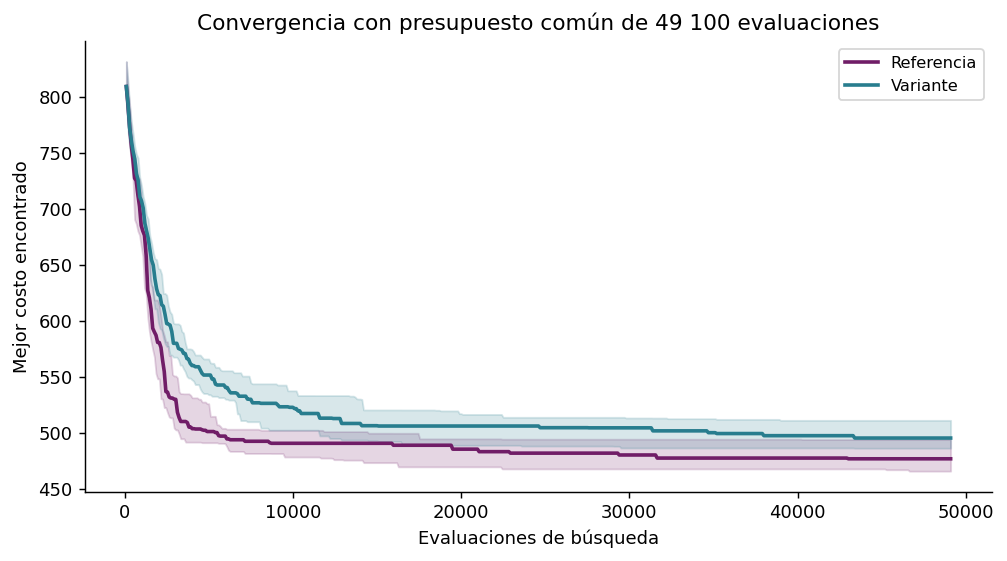

In [30]:
# Figura 1. Convergencia bajo presupuesto común.
fig, ax = plt.subplots(figsize=(9, 4.5))
for nombre in ("Referencia", "Variante"):
    banda(ax, historial[historial.configuracion == nombre], "mejor", nombre, COLOR[nombre])
ax.set_xlabel("Evaluaciones de búsqueda")
ax.set_ylabel("Mejor costo encontrado")
ax.set_title("Convergencia con presupuesto común de 49 100 evaluaciones")
ax.legend(fontsize=9)
guardar(fig, "ae_a02_01_convergencia.png")

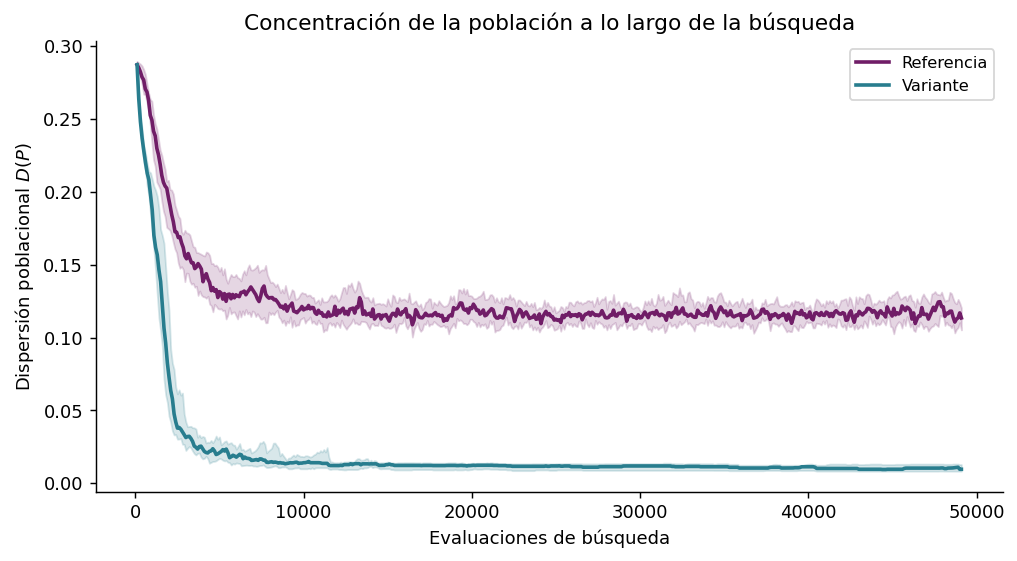

In [31]:
# Figura 2. Dispersión poblacional: lo que el costo final no muestra.
fig, ax = plt.subplots(figsize=(9, 4.5))
for nombre in ("Referencia", "Variante"):
    banda(ax, historial[historial.configuracion == nombre], "dispersion", nombre, COLOR[nombre])
ax.set_xlabel("Evaluaciones de búsqueda")
ax.set_ylabel("Dispersión poblacional $D(P)$")
ax.set_title("Concentración de la población a lo largo de la búsqueda")
ax.legend(fontsize=9)
guardar(fig, "ae_a02_02_dispersion.png")

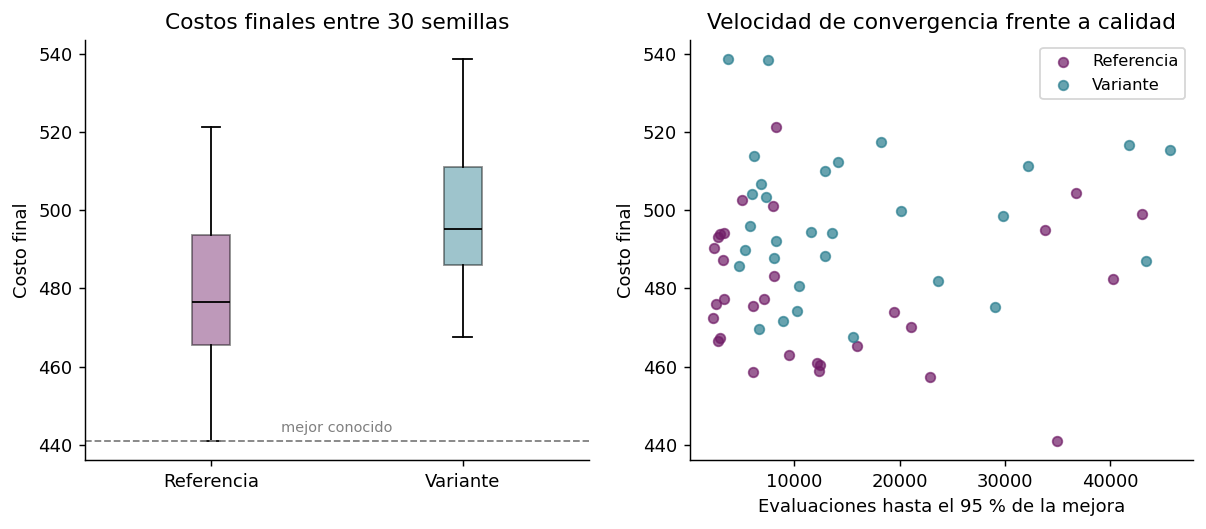

In [32]:
# Figura 3. Distribución de los costos finales entre las treinta semillas.
fig, axs = plt.subplots(1, 2, figsize=(11, 4.2))
datos = [tabla[tabla.configuracion == n].costo.values for n in ("Referencia", "Variante")]
caja = axs[0].boxplot(datos, tick_labels=["Referencia", "Variante"], patch_artist=True,
                      medianprops=dict(color="black"))
for parche, nombre in zip(caja["boxes"], ("Referencia", "Variante")):
    parche.set_facecolor(COLOR[nombre]); parche.set_alpha(0.45)
axs[0].axhline(MEJOR_CONOCIDO, color="gray", linestyle="--", linewidth=1)
axs[0].annotate("mejor conocido", (1.5, MEJOR_CONOCIDO), textcoords="offset points",
                xytext=(0, 5), ha="center", fontsize=8, color="gray")
axs[0].set_ylabel("Costo final")
axs[0].set_title("Costos finales entre 30 semillas")
for i, nombre in enumerate(("Referencia", "Variante")):
    sub = tabla[tabla.configuracion == nombre]
    axs[1].scatter(sub.evaluaciones_95, sub.costo, color=COLOR[nombre], alpha=0.7,
                   s=28, label=nombre)
axs[1].set_xlabel("Evaluaciones hasta el 95 % de la mejora")
axs[1].set_ylabel("Costo final")
axs[1].set_title("Velocidad de convergencia frente a calidad")
axs[1].legend(fontsize=9)
guardar(fig, "ae_a02_03_distribucion.png")

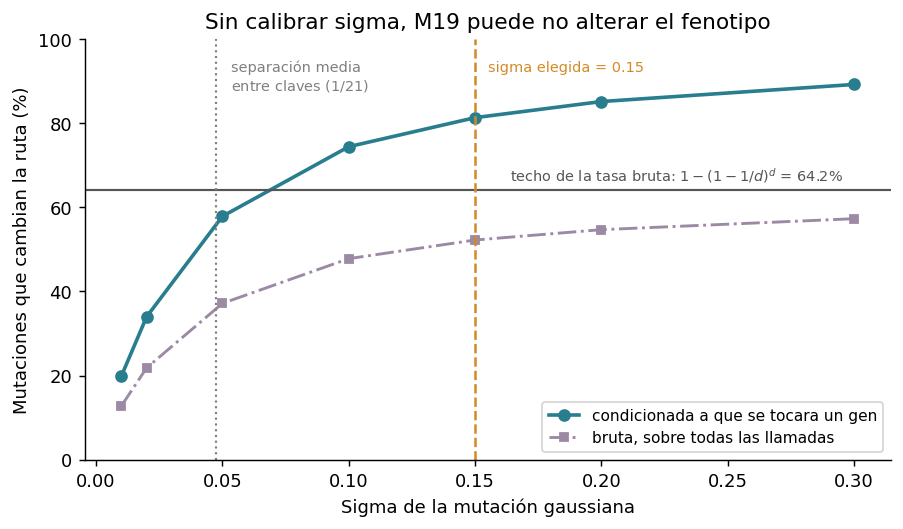

In [33]:
# Figura 4. Calibración de sigma para M19.
fig, ax = plt.subplots(figsize=(8, 4.2))
ax.plot(calibracion.sigma, 100 * calibracion.tasa_condicional, marker="o",
        color=COLOR["Variante"], linewidth=2, label="condicionada a que se tocara un gen")
ax.plot(calibracion.sigma, 100 * calibracion.tasa_bruta, marker="s", markersize=4,
        color="#9C8AA5", linewidth=1.6, linestyle="-.", label="bruta, sobre todas las llamadas")
ax.axhline(100 * TECHO, color="#555555", linestyle="-", linewidth=1.2)
ax.annotate(f"techo de la tasa bruta: $1-(1-1/d)^d$ = {100*TECHO:.1f}%",
            (SIGMAS[-1], 100 * TECHO), textcoords="offset points", xytext=(-6, 5),
            ha="right", fontsize=8, color="#555555")
ax.axvline(1 / 21, color="gray", linestyle=":", linewidth=1.2)
ax.annotate("separación media\nentre claves ($1/21$)", (1 / 21, 88),
            textcoords="offset points", xytext=(8, 0), fontsize=8, color="gray")
ax.axvline(VARIANTE.sigma, color="#D58A28", linestyle="--", linewidth=1.4)
ax.annotate(f"sigma elegida = {VARIANTE.sigma}", (VARIANTE.sigma, 95),
            textcoords="offset points", xytext=(7, 0), fontsize=8, color="#D58A28",
            va="top")
ax.set_ylim(0, 100)
ax.set_xlabel("Sigma de la mutación gaussiana")
ax.set_ylabel("Mutaciones que cambian la ruta (%)")
ax.set_title("Sin calibrar sigma, M19 puede no alterar el fenotipo")
ax.legend(fontsize=8.5, loc="lower right")
guardar(fig, "ae_a02_04_calibracion_sigma.png")

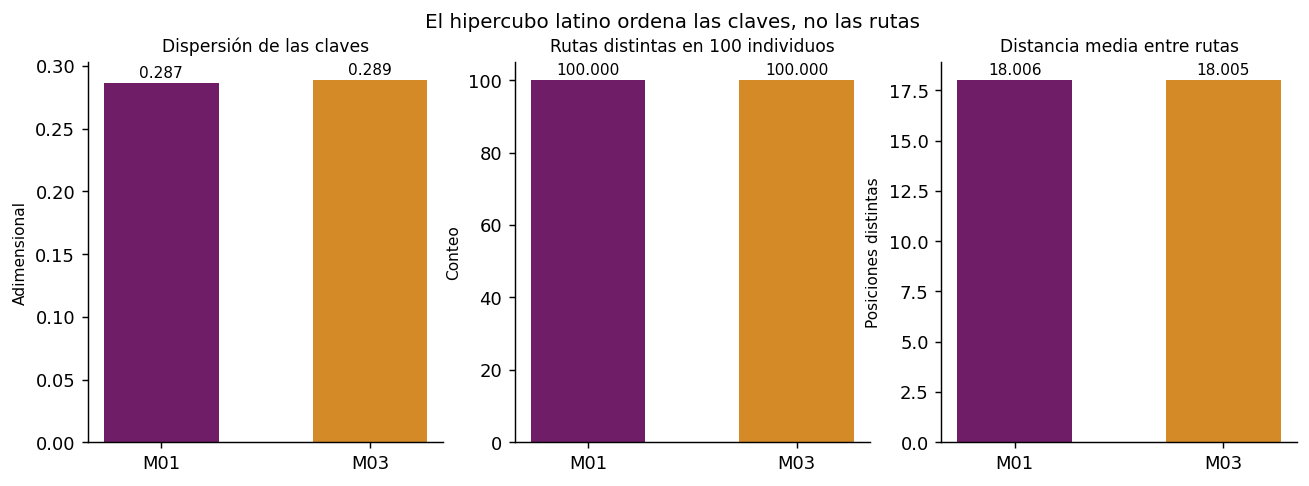

In [34]:
# Figura 5. M01 frente a M03: la estructura que el decodificador descarta.
fig, axs = plt.subplots(1, 3, figsize=(12, 3.8))
metricas_div = [("dispersion_claves", "Dispersión de las claves", "Adimensional"),
                ("rutas_distintas", "Rutas distintas en 100 individuos", "Conteo"),
                ("hamming_media", "Distancia media entre rutas", "Posiciones distintas")]
for ax, (col, titulo, unidad) in zip(axs, metricas_div):
    valores = [diversidad_inicial[diversidad_inicial.metodo == m][col].mean()
               for m in ("M01 uniforme", "M03 hipercubo latino")]
    ax.bar(["M01", "M03"], valores, color=["#701D67", "#D58A28"], width=0.55)
    ax.set_title(titulo, fontsize=9.5)
    ax.set_ylabel(unidad, fontsize=8.5)
    for i, v in enumerate(valores):
        ax.annotate(f"{v:.3f}", (i, v), textcoords="offset points", xytext=(0, 3),
                    ha="center", fontsize=8.5)
fig.suptitle("El hipercubo latino ordena las claves, no las rutas", fontsize=11)
guardar(fig, "ae_a02_05_m01_vs_m03.png")

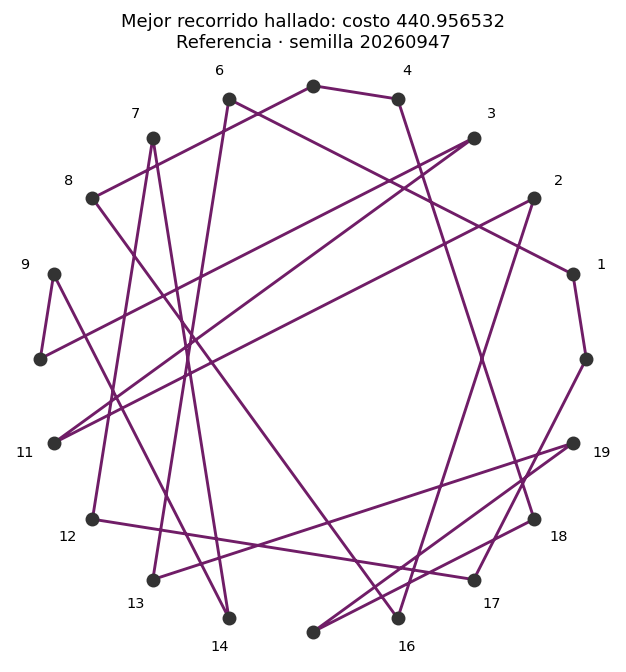

Las ciudades se dibujan en círculo por comodidad de lectura.
La longitud de un segmento NO representa su costo: la matriz es sintética
y no cumple la desigualdad triangular.


In [35]:
# Figura 6. El mejor recorrido hallado, sobre el esquema circular de ciudades.
mejor = min(corridas, key=lambda r: r["costo"])
angulos = np.linspace(0, 2 * np.pi, len(MATRIZ), endpoint=False)
puntos = np.column_stack((np.cos(angulos), np.sin(angulos)))
ruta = np.array(mejor["ruta"])
ciclo = np.append(ruta, ruta[0])
fig, ax = plt.subplots(figsize=(6, 6))
ax.plot(puntos[ciclo, 0], puntos[ciclo, 1], color=COLOR[mejor["configuracion"]],
        linewidth=1.6, zorder=1)
ax.scatter(puntos[:, 0], puntos[:, 1], color="#333333", s=45, zorder=2)
for ciudad, (x, y) in enumerate(puntos):
    ax.annotate(str(ciudad), (x * 1.11, y * 1.11), ha="center", va="center", fontsize=8)
ax.set_aspect("equal"); ax.axis("off")
ax.set_title(f"Mejor recorrido hallado: costo {mejor['costo']:.6f}\n"
             f"{mejor['configuracion']} · semilla {mejor['semilla']}", fontsize=10)
guardar(fig, "ae_a02_06_mejor_ruta.png")
print("Las ciudades se dibujan en círculo por comodidad de lectura.")
print("La longitud de un segmento NO representa su costo: la matriz es sintética")
print("y no cumple la desigualdad triangular.")

## I. Trazabilidad

El manifiesto registra versiones, configuración, semillas y una huella SHA-256 por cada CSV
producido. Permite comprobar más tarde que un archivo corresponde a esta ejecución y no a otra.
Los tiempos no tienen por qué repetirse entre equipos, y una misma semilla puede depender de la
versión de las bibliotecas.

In [36]:
import hashlib
from dataclasses import asdict
from datetime import datetime, timezone

manifiesto = dict(
    fecha_utc=datetime.now(timezone.utc).isoformat(),
    python=sys.version, entorno="conda environment: science",
    plataforma=platform.platform(),
    numpy=np.__version__, pandas=pd.__version__, matplotlib=matplotlib.__version__,
    instancia=dict(ciudades=int(len(MATRIZ)), semilla_datos=SEMILLA_DATOS,
                   modo="simetrica_aleatoria",
                   nota="D=(A+A.T)/2 con A uniforme en [0,100); sin desigualdad triangular"),
    semillas_algoritmicas=SEMILLAS,
    configuraciones={c.nombre: asdict(c) for c in (REFERENCIA, VARIANTE)},
    presupuesto_evaluaciones=49_100,
    corridas=len(corridas), auditorias_finales=int(tabla.auditorias.sum()),
    mejor_conocido=MEJOR_CONOCIDO,
    sigma_elegida=float(VARIANTE.sigma), tasa_bruta_sigma=tasa_elegida,
    tasa_condicional_sigma=tasa_condicional, techo_tasa_bruta=TECHO,
    umbral_acierto_pct=1.0, pruebas_automatizadas=10,
    alcance="Instancia sintética única; no se certifica optimalidad ni superioridad general.",
)
manifiesto["sha256_resultados"] = {
    p.name: hashlib.sha256(p.read_bytes()).hexdigest()
    for p in sorted(RESULTADOS.glob("*.csv"))}
(RESULTADOS / "manifiesto.json").write_text(
    json.dumps(manifiesto, ensure_ascii=False, indent=2) + "\n")

print("resultados/:", ", ".join(p.name for p in sorted(RESULTADOS.iterdir())))
print("figuras/:", ", ".join(p.name for p in sorted(FIGURAS.iterdir())))

resultados/: RESUMEN.md, calibracion_sigma.csv, corridas.csv, diversidad_inicial.csv, historiales.csv, manifiesto.json, resumen.csv
figuras/: ae_a02_01_convergencia.png, ae_a02_02_dispersion.png, ae_a02_03_distribucion.png, ae_a02_04_calibracion_sigma.png, ae_a02_05_m01_vs_m03.png, ae_a02_06_mejor_ruta.png


## J. Paquete de resultados para el informe

La celda siguiente escribe `resultados/RESUMEN.md` con todas las cifras de esta ejecución, los pies
de figura y de tabla en formato APA, y la lectura técnica de cada resultado. Se genera desde los
objetos de datos y no se transcribe a mano, de modo que el informe y el cuadernillo no puedan
divergir.

Es un insumo para redactar el informe, no el informe.

In [37]:
def fila(nombre, columna):
    return float(resumen.loc[resumen.configuracion == nombre, columna].iloc[0])


ref, var = "Referencia", "Variante"
dif_media = fila(var, "costo_medio") - fila(ref, "costo_medio")
dif_pct = 100.0 * dif_media / fila(ref, "costo_medio")
gana = "la variante" if dif_media < 0 else "la referencia"

lineas = [
    "# Resumen de resultados — Actividad 02",
    "",
    "Cifras generadas por `Actividad_02_Agente_Viajero.ipynb`. Insumo para el informe.",
    f"Ejecución del {manifiesto['fecha_utc'][:10]} · "
    f"NumPy {np.__version__} · pandas {pd.__version__}.",
    "",
    "## 1. Configuraciones comparadas",
    "",
    "| Etapa | Referencia | Variante |",
    "|---|---|---|",
    "| 1. Inicialización | M01 uniforme | M01 uniforme (conservada) |",
    "| 2. Evaluación | M05 directa | M05 directa (conservada) |",
    "| 3. Selección | M12 torneo ($k=3$) | M11 ranking lineal ($s=1.7$) |",
    "| 4. Recombinación | M14 uniforme ($q=0.5$) | M15 aritmético ($\\alpha\\sim U(0,1)$) |",
    f"| 5. Mutación | M18 reinicio ($p=1/d$) | M19 gaussiana ($p=1/d$, $\\sigma={VARIANTE.sigma}$) |",
    "| 6. Reemplazo | M22 generacional elitista ($e=2$) | M23 $(\\mu+\\lambda)$, $\\lambda=100$ |",
    "| 7. Paro | M25 500 generaciones | M26 presupuesto de 49 100 |",
    "",
    "*Tabla 1. Métodos de cada etapa en las dos configuraciones comparadas. "
    "Elaboración propia a partir de la guía de los treinta métodos.*",
    "",
    "## 2. Las nueve métricas",
    "",
    "| Métrica | Eje | Referencia | Variante |",
    "|---|---|---:|---:|",
    f"| 1. Costo final (mediana) | Calidad | {fila(ref,'costo_mediana'):.6f} | {fila(var,'costo_mediana'):.6f} |",
    f"| 2. Mejora relativa media | Calidad | {fila(ref,'mejora_media_pct'):.3f} % | {fila(var,'mejora_media_pct'):.3f} % |",
    f"| 3. Costo medio | Calidad | {fila(ref,'costo_medio'):.6f} | {fila(var,'costo_medio'):.6f} |",
    f"| 4. Desviación estándar | Calidad | {fila(ref,'costo_desviacion'):.6f} | {fila(var,'costo_desviacion'):.6f} |",
    f"| 5. Evaluaciones | Esfuerzo | {int(fila(ref,'evaluaciones'))} | {int(fila(var,'evaluaciones'))} |",
    f"| 6. Tiempo (mediana) | Esfuerzo | {fila(ref,'segundos_mediana'):.3f} s | {fila(var,'segundos_mediana'):.3f} s |",
    f"| 7. Dispersión final media | Búsqueda | {fila(ref,'dispersion_final'):.6f} | {fila(var,'dispersion_final'):.6f} |",
    f"| 8. Tasa de acierto (1 %) | Búsqueda | {fila(ref,'acierto_pct'):.1f} % | {fila(var,'acierto_pct'):.1f} % |",
    f"| 9. Evaluaciones al 95 % | Búsqueda | {int(fila(ref,'evaluaciones_95_mediana'))} | {int(fila(var,'evaluaciones_95_mediana'))} |",
    "",
    "*Tabla 2. Las nueve métricas sobre 30 semillas por configuración, con presupuesto idéntico de "
    "49 100 evaluaciones de búsqueda. Elaboración propia desde `resumen.csv`. Las métricas 3 y 4 se "
    "calculan entre corridas, no entre individuos de una generación.*",
    "",
    "### Intervalos observados",
    "",
    f"- Referencia: mínimo {fila(ref,'costo_minimo'):.6f}, máximo {fila(ref,'costo_maximo'):.6f}.",
    f"- Variante: mínimo {fila(var,'costo_minimo'):.6f}, máximo {fila(var,'costo_maximo'):.6f}.",
    f"- Mejor costo conocido entre las {len(corridas)} corridas: **{MEJOR_CONOCIDO:.6f}** "
    f"({mejor['configuracion']}, semilla {mejor['semilla']}).",
    f"- Generaciones consumidas: referencia {int(fila(ref,'generaciones'))}, "
    f"variante {int(fila(var,'generaciones'))}. El presupuesto es el mismo; el trabajo por "
    "generación no.",
    "",
    "## 3. Lectura técnica",
    "",
    f"**Calidad.** El costo medio de {gana} es menor por {abs(dif_media):.6f} unidades "
    f"({abs(dif_pct):.3f} %). Con treinta semillas por configuración y desviaciones de "
    f"{fila(ref,'costo_desviacion'):.4f} y {fila(var,'costo_desviacion'):.4f}, esa distancia debe "
    "leerse junto a la dispersión de cada grupo y no como una diferencia establecida: no se aplicó "
    "prueba estadística alguna.",
    "",
    f"**Esfuerzo.** Ambas configuraciones consumieron exactamente {int(fila(ref,'evaluaciones'))} "
    "evaluaciones de búsqueda más una auditoría final. Ésa es la razón de haber sustituido M25 por "
    "M26: con M23 el trabajo por generación pasa de 98 a 100 hijos, y comparar por generaciones "
    "habría dado a la variante un 2 % más de evaluaciones.",
    "",
    f"**Concentración.** La dispersión final media es {fila(ref,'dispersion_final'):.6f} en la "
    f"referencia y {fila(var,'dispersion_final'):.6f} en la variante. La diferencia era previsible "
    "y está anotada en el propio operador: M15 sólo interpola, de modo que nunca genera claves "
    "fuera del intervalo de los padres y contrae la población hacia su centro. M18, al reiniciar "
    "una clave con un uniforme nuevo, repone variedad que M19 no repone porque sólo desplaza.",
    "",
    f"**Velocidad.** La mediana de evaluaciones para alcanzar el 95 % de la mejora propia es "
    f"{int(fila(ref,'evaluaciones_95_mediana'))} en la referencia y "
    f"{int(fila(var,'evaluaciones_95_mediana'))} en la variante. Es una medida de rapidez, no de "
    "calidad: llegar antes al 95 % del propio recorrido no implica terminar mejor.",
    "",
    "## 4. Dos comprobaciones que sostienen el diseño",
    "",
    f"**Calibración de sigma.** La comprobación existe porque el material advierte que en esta "
    "representación un desplazamiento pequeño puede conservar el orden de las claves: la mutación "
    "cambiaría el genotipo sin cambiar el fenotipo. La separación media entre claves consecutivas "
    f"es $1/21\\approx{1/21:.4f}$.",
    "",
    f"Con $\\sigma={VARIANTE.sigma}$ el {100*tasa_elegida:.2f} % de todas las llamadas altera la "
    f"ruta. Esa cifra bruta **no debe leerse como que la otra mitad falla**: la máscara es "
    f"Bernoulli por gen con $p=1/d$, así que en el $100(1-p)^d = {100*(1-TECHO):.2f}$ % de las "
    "llamadas no se selecciona ningún gen y el individuo sale intacto con cualquier sigma. El techo "
    f"alcanzable es por tanto $1-(1-p)^d = {100*TECHO:.2f}$ %.",
    "",
    f"La cantidad que mide el operador es la tasa **condicionada** a que la máscara haya tocado "
    f"algún gen: **{100*tasa_condicional:.2f} %** con la sigma elegida. La tabla "
    "`calibracion_sigma.csv` recoge las tres cantidades para siete valores de sigma.",
    "",
    "**M03 medido, no supuesto.** El hipercubo latino se descartó en la inicialización con un "
    "argumento que se comprobó empíricamente:",
    "",
    "| Método | Dispersión de claves | Rutas distintas de 100 | Distancia media entre rutas |",
    "|---|---:|---:|---:|",
]
for m in ("M01 uniforme", "M03 hipercubo latino"):
    s = resumen_div[resumen_div.metodo == m].iloc[0]
    lineas.append(f"| {m} | {s.dispersion_claves:.4f} | {s.rutas_distintas:.1f} | "
                  f"{s.hamming_media:.4f} |")
lineas += [
    "",
    "*Tabla 3. Diversidad de poblaciones iniciales generadas con M01 y con M03, promediada sobre "
    "10 repeticiones de 100 individuos. Elaboración propia desde `diversidad_inicial.csv`. La "
    "distancia entre rutas se mide sobre el ciclo ya rotado para empezar en la ciudad 0; la "
    "inversión del sentido no se normaliza y afecta por igual a ambos métodos.*",
    "",
    f"El hipercubo **sí cumple lo que promete sobre las claves**: alcanza una dispersión de "
    f"{resumen_div[resumen_div.metodo=='M03 hipercubo latino'].dispersion_claves.iloc[0]:.4f}, "
    f"prácticamente el valor teórico máximo de una muestra uniforme, "
    f"$\\sqrt{{1/12}}\\approx{np.sqrt(1/12):.4f}$, mientras que M01 se queda en "
    f"{resumen_div[resumen_div.metodo=='M01 uniforme'].dispersion_claves.iloc[0]:.4f} por efecto "
    "del muestreo finito.",
    "",
    "**Y sin embargo esa ventaja no llega a las rutas.** La distancia media entre recorridos es "
    f"{resumen_div[resumen_div.metodo=='M01 uniforme'].hamming_media.iloc[0]:.4f} con M01 y "
    f"{resumen_div[resumen_div.metodo=='M03 hipercubo latino'].hamming_media.iloc[0]:.4f} con M03 "
    "—idénticas hasta la segunda cifra decimal— y ambos métodos producen 100 rutas distintas de "
    "100 individuos. La razón es la representación: el recorrido depende sólo del orden relativo "
    "de las claves, y `argsort` descarta la estratificación que el método construye. Es el "
    "resultado que anticipaba la sección C.1, medido en lugar de supuesto.",
    "",
    "## 5. Figuras",
    "",
]
pies = [
    ("ae_a02_01_convergencia.png",
     "Convergencia del mejor costo frente a las evaluaciones de búsqueda, con mediana y banda "
     "intercuartil sobre 30 semillas. Elaboración propia. El eje horizontal es el presupuesto "
     "común, no el número de generaciones."),
    ("ae_a02_02_dispersion.png",
     "Dispersión poblacional a lo largo de la búsqueda, con mediana y banda intercuartil sobre 30 "
     "semillas. Elaboración propia. Cero indicaría una población de individuos idénticos."),
    ("ae_a02_03_distribucion.png",
     "Distribución de los costos finales entre semillas y relación entre velocidad de convergencia "
     "y calidad final. Elaboración propia. La línea discontinua marca el mejor costo hallado en el "
     "estudio, que no es un óptimo certificado."),
    ("ae_a02_04_calibracion_sigma.png",
     "Fracción de mutaciones M19 que alteran la ruta decodificada, para siete valores de sigma. "
     "Elaboración propia sobre 20 000 mutaciones por valor."),
    ("ae_a02_05_m01_vs_m03.png",
     "Comparación de M01 y M03 en dispersión de claves, rutas distintas y distancia media entre "
     "rutas. Elaboración propia sobre 10 poblaciones de 100 individuos por método."),
    ("ae_a02_06_mejor_ruta.png",
     f"Mejor recorrido hallado en el estudio, con costo {MEJOR_CONOCIDO:.6f}. Elaboración propia. "
     "Las ciudades se disponen en círculo por comodidad de lectura: la longitud de un segmento no "
     "representa su costo, porque la matriz es sintética y no cumple la desigualdad triangular."),
]
for i, (archivo, pie) in enumerate(pies, start=1):
    lineas += [f"![[{archivo}]]", f"*Figura {i}. {pie}*", ""]

lineas += [
    "## 6. Lo que estos resultados no permiten concluir",
    "",
    "- **Optimalidad.** No se enumeró el espacio y no hay certificado. El «mejor conocido» es el "
    "menor costo de estas sesenta corridas.",
    "- **Superioridad general.** Los resultados describen una instancia sintética de veinte "
    "ciudades con un presupuesto fijo. No se extrapolan a otras instancias, tamaños o presupuestos.",
    "- **Significancia estadística.** Se informan media, desviación, mediana y cuartiles sobre 30 "
    "semillas. No se aplicó ninguna prueba de hipótesis ni se calcularon intervalos de confianza.",
    "- **Efecto de cada etapa por separado.** Se cambiaron cinco métodos a la vez; el diseño no "
    "permite atribuir la diferencia observada a uno de ellos. Aislarlo exigiría un experimento "
    "factorial que no se realizó.",
    "",
    "## 7. Reproducibilidad",
    "",
    "- Entorno conda `science`, Python "
    f"{sys.version.split()[0]}, NumPy {np.__version__}, pandas {pd.__version__}, "
    f"Matplotlib {matplotlib.__version__}.",
    "- Una sola orden desde la carpeta del proyecto:",
    "",
    "  ```bash",
    "  conda run -n science jupyter nbconvert --to notebook --execute --inplace \\",
    "    --ExecutePreprocessor.timeout=3600 Actividad_02_Agente_Viajero.ipynb",
    "  ```",
    "",
    f"- Semilla de datos {SEMILLA_DATOS}; semillas algorítmicas {SEMILLAS[0]}–{SEMILLAS[-1]}.",
    "- Diez pruebas automatizadas se ejecutan antes del experimento; si una falla, el cuadernillo "
    "se detiene.",
    "- `resultados/manifiesto.json` conserva versiones, configuración y huellas SHA-256 de cada CSV.",
    "",
]
(RESULTADOS / "RESUMEN.md").write_text("\n".join(lineas) + "\n", encoding="utf-8")
print(f"Escrito resultados/RESUMEN.md ({len(lineas)} líneas)")
print(f"\nCosto medio — referencia: {fila(ref,'costo_medio'):.6f} | "
      f"variante: {fila(var,'costo_medio'):.6f}")
print(f"Diferencia: {dif_media:+.6f} ({dif_pct:+.3f} %) — menor es mejor")

Escrito resultados/RESUMEN.md (114 líneas)

Costo medio — referencia: 478.949784 | variante: 497.401168
Diferencia: +18.451384 (+3.852 %) — menor es mejor


## K. Interpretación

**Sobre el diseño.** Las dos configuraciones recorren la misma función, comparten instancia,
población, probabilidad de cruce y tasa de mutación, y consumen exactamente el mismo número de
evaluaciones. Lo único que las separa es el método de cinco etapas. Esa igualdad no se obtuvo por
casualidad: exigió sustituir el criterio de paro, porque M23 cambia el trabajo por generación y
contar generaciones habría medido esfuerzos distintos.

**Sobre lo que el costo final no dice.** Si el trabajo se hubiera limitado a las métricas de
calidad, la conclusión sería una cifra y su signo. Las métricas del cuarto eje muestran algo que esa
cifra oculta: cuánta variedad conserva cada configuración al terminar y con qué rapidez llega cada
una a su propio techo. La dispersión final, en particular, tiene una explicación mecánica
identificable en el operador —M15 interpola y nunca extrapola, M19 desplaza y nunca repone— y no en
el azar de las semillas.

**Sobre los límites.** Se cambiaron cinco métodos simultáneamente, de modo que ninguna diferencia
puede atribuirse a uno solo. Aislar el efecto de cada etapa exigiría un diseño factorial que aquí no
se hizo. Tampoco se aplicó prueba estadística: se informan mediana, cuartiles, media y desviación
sobre treinta semillas, y nada más. Y todo ocurre sobre una única instancia sintética de veinte
ciudades.

**Sobre el resultado, sea cual sea su signo.** Una variante correctamente implementada que no supera
a la referencia es un resultado válido y se informa como tal. Lo que invalidaría el trabajo sería
elegir las semillas favorables, ajustar sigma o la presión después de ver los resultados, o comparar
configuraciones con presupuestos distintos. Nada de eso se hizo, y el manifiesto permite comprobarlo.

## Referencias

Aguilar Ortiz, J. (s. f.-a). *Métodos matemáticos de los algoritmos genéticos: formulación e
implementación de sus siete etapas* [Material de clase, SEMANA-02].

Aguilar Ortiz, J. (s. f.-b). *Agente viajero: algoritmo genético con siete etapas comentadas*
[Código Python proporcionado para la materia].

Bean, J. C. (1994). Genetic algorithms and random keys for sequencing and optimization. *ORSA
Journal on Computing, 6*(2), 154–160. https://doi.org/10.1287/ijoc.6.2.154

Blickle, T., & Thiele, L. (1996). A comparison of selection schemes used in evolutionary algorithms.
*Evolutionary Computation, 4*(4), 361–394. https://doi.org/10.1162/evco.1996.4.4.361

Eiben, A. E., & Smith, J. E. (2015). *Introduction to evolutionary computing* (2.ª ed.). Springer.
https://doi.org/10.1007/978-3-662-44874-8

Harris, C. R., Millman, K. J., van der Walt, S. J., Gommers, R., Virtanen, P., Cournapeau, D., et
al. (2020). Array programming with NumPy. *Nature, 585*(7825), 357–362.
https://doi.org/10.1038/s41586-020-2649-2

Rardin, R. L., & Uzsoy, R. (2001). Experimental evaluation of heuristic optimization algorithms: A
tutorial. *Journal of Heuristics, 7*, 261–304. https://doi.org/10.1023/A:1011319115230

---

Se empleó asistencia de inteligencia artificial para la programación y la redacción. Las cifras no
proceden de esa asistencia: se obtienen ejecutando las celdas y las diez pruebas que acompañan al
cuadernillo.